In [1]:
#прочитати набір даних про каву 
import pandas as pd
import os.path 
import requests
from io import StringIO
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np


url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-07-07/coffee_ratings.csv' 
# перевіряється наявність файлу 'coffee_ratings.csv' в поточному каталозі. 
if not os.path.exists('/workspaces/HW6/coffee_ratings.csv'):
    response = requests.get(url)
    df = pd.read_csv(StringIO(response.text))
    df.to_csv('coffee_ratings.csv', index=False)
else:
    df = pd.read_csv('coffee_ratings.csv')
    print('Файл вже існує')


Файл вже існує


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_cup_points       1339 non-null   float64
 1   species                1339 non-null   str    
 2   owner                  1332 non-null   str    
 3   country_of_origin      1338 non-null   str    
 4   farm_name              980 non-null    str    
 5   lot_number             276 non-null    str    
 6   mill                   1021 non-null   str    
 7   ico_number             1180 non-null   str    
 8   company                1130 non-null   str    
 9   altitude               1113 non-null   str    
 10  region                 1280 non-null   str    
 11  producer               1107 non-null   str    
 12  number_of_bags         1339 non-null   int64  
 13  bag_weight             1339 non-null   str    
 14  in_country_partner     1339 non-null   str    
 15  harvest_year   

In [3]:
df.head()

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [4]:
df.describe()

,total_cup_points,number_of_bags,aroma,flavor,aftertaste,acidity,body,balance,uniformity,clean_cup,sweetness,cupper_points,moisture,category_one_defects,quakers,category_two_defects,altitude_low_meters,altitude_high_meters,altitude_mean_meters
count,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1339.000000,1338.000000,1339.000000,1109.000000,1109.000000,1109.000000
mean,82.089851,154.182972,7.566706,7.520426,7.401083,7.535706,7.517498,7.518013,9.834877,9.835108,9.856692,7.503376,0.088379,0.479462,0.173393,3.556385,1750.713315,1799.347775,1775.030545
std,3.500575,129.987162,0.377560,0.398442,0.404463,0.379827,0.370064,0.408943,0.554591,0.763946,0.616102,0.473464,0.048287,2.549683,0.832121,5.312541,8669.440545,8668.805771,8668.626080
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,81.080000,14.000000,7.420000,7.330000,7.250000,7.330000,7.330000,7.330000,10.000000,10.000000,10.000000,7.250000,0.090000,0.000000,0.000000,0.000000,1100.000000,1100.000000,1100.000000
50%,82.500000,175.000000,7.580000,7.580000,7.420000,7.580000,7.500000,7.500000,10.000000,10.000000,10.000000,7.500000,0.110000,0.000000,0.000000,2.000000,1310.640000,1350.000000,1310.640000
75%,83.670000,275.000000,7.750000,7.750000,7.580000,7.750000,7.670000,7.750000,10.000000,10.000000,10.000000,7.750000,0.120000,0.000000,0.000000,4.000000,1600.000000,1650.000000,1600.000000
max,90.580000,1062.000000,8.750000,8.830000,8.670000,8.750000,8.580000,8.750000,10.000000,10.000000,10.000000,10.000000,0.280000,63.000000,11.000000,55.000000,190164.000000,190164.000000,190164.000000


# 1. Які країни є великими експортерами кави?


In [5]:
df_most_exporters = df['country_of_origin'].value_counts().head(10)
print("Топ 10 країн-експортерів кави:")
print(df_most_exporters)

Топ 10 країн-експортерів кави:
country_of_origin
Mexico                          236
Colombia                        183
Guatemala                       181
Brazil                          132
Taiwan                           75
United States (Hawaii)           73
Honduras                         53
Costa Rica                       51
Ethiopia                         44
Tanzania, United Republic Of     40
Name: count, dtype: int64


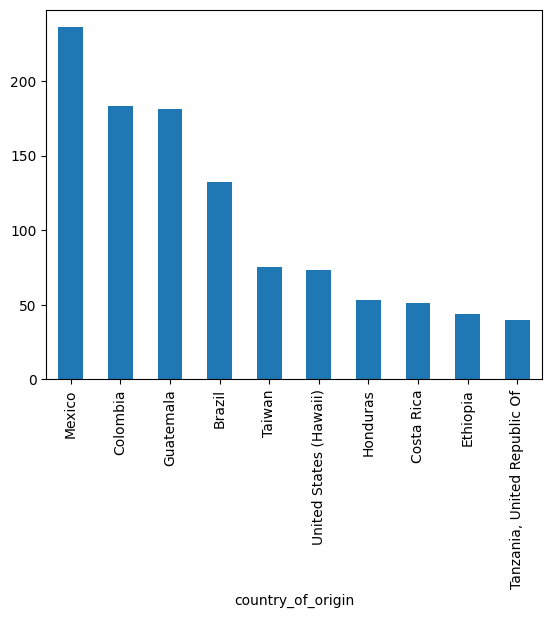

In [6]:
df_most_exporters.plot(kind='bar')
plt.show()

У першому пункті знайдено топ 10 - країн експортерів кави

# 2. Які кореляції між різними показниками оцінки кави?

In [7]:
print("Оцінки кави (числові колонки):")
number_columns = df.select_dtypes(include='number').columns.tolist()
print(number_columns)

Оцінки кави (числові колонки):
['total_cup_points', 'number_of_bags', 'aroma', 'flavor', 'aftertaste', 'acidity', 'body', 'balance', 'uniformity', 'clean_cup', 'sweetness', 'cupper_points', 'moisture', 'category_one_defects', 'quakers', 'category_two_defects', 'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters']


In [8]:
df_number_columns_without = df[number_columns].drop(columns=['sweetness', 'uniformity', 'clean_cup','altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'], errors='ignore')
df_number_columns_without.head()

,total_cup_points,number_of_bags,aroma,flavor,aftertaste,acidity,body,balance,cupper_points,moisture,category_one_defects,quakers,category_two_defects
0,90.58,300,8.67,8.83,8.67,8.75,8.50,8.42,8.75,0.12,0,0.0,0
1,89.92,300,8.75,8.67,8.50,8.58,8.42,8.42,8.58,0.12,0,0.0,1
2,89.75,5,8.42,8.50,8.42,8.42,8.33,8.42,9.25,0.00,0,0.0,0
3,89.00,320,8.17,8.58,8.42,8.42,8.50,8.25,8.67,0.11,0,0.0,2
4,88.83,300,8.25,8.50,8.25,8.50,8.42,8.33,8.58,0.12,0,0.0,2


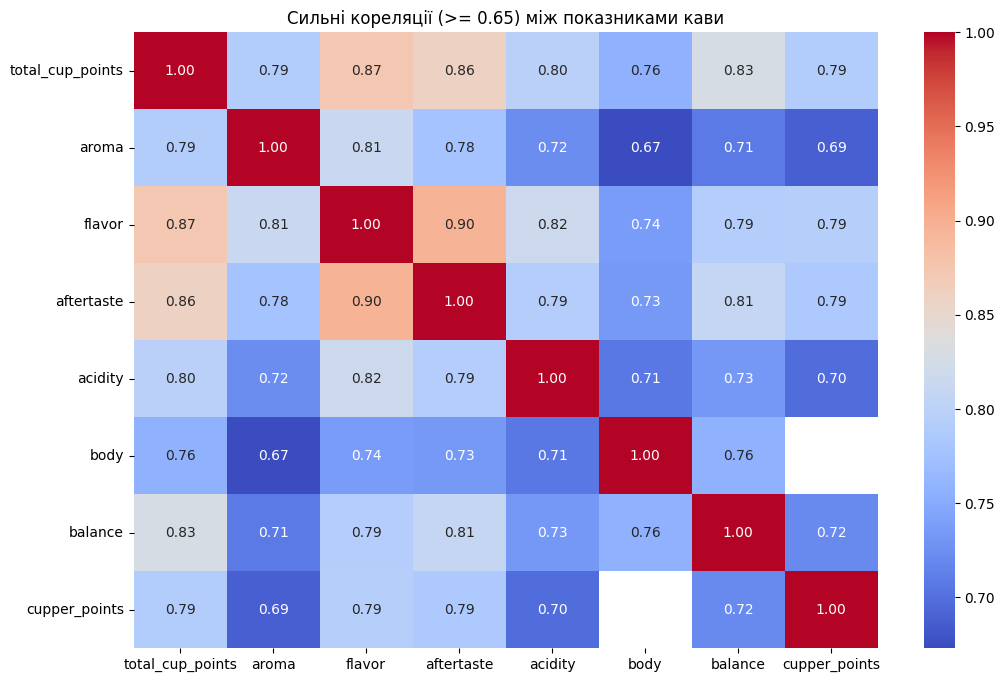

In [9]:
corr_matrix = df_number_columns_without.corr()
high_corr_features = corr_matrix.columns[(corr_matrix.values >= 0.65).sum(axis=0) > 1].tolist()
filtered_corr = df_number_columns_without[high_corr_features].corr()
new_mask = filtered_corr < 0.65

plt.figure(figsize=(12, 8)) 
sns.heatmap(filtered_corr, annot=True, mask=new_mask, cmap='coolwarm', fmt='.2f')

plt.title('Сильні кореляції (>= 0.65) між показниками кави')
plt.show()

У другому пункті я знайшла залежності між найбільш впливовими характеристиками до кави ,ми можемо на тепловій мапі спостерігати залежнітсь між різними характеристиками за якими кава є хорошою. Три найголовніші показники ми можемо одразу помітити: 1 показник - смак(flavor - 87%), 2 - показник це після смак(aftertaste - 86%), 3 - показник баланс(balance - 83%).

# 3. Який (якщо є) вплив кольору зерен на загальний сорт кави?

In [10]:
df.columns # цей вивід зроблений для того щоб побачити які взагалі є колонки в даних

Index(['total_cup_points', 'species', 'owner', 'country_of_origin',
       'farm_name', 'lot_number', 'mill', 'ico_number', 'company', 'altitude',
       'region', 'producer', 'number_of_bags', 'bag_weight',
       'in_country_partner', 'harvest_year', 'grading_date', 'owner_1',
       'variety', 'processing_method', 'aroma', 'flavor', 'aftertaste',
       'acidity', 'body', 'balance', 'uniformity', 'clean_cup', 'sweetness',
       'cupper_points', 'moisture', 'category_one_defects', 'quakers', 'color',
       'category_two_defects', 'expiration', 'certification_body',
       'certification_address', 'certification_contact', 'unit_of_measurement',
       'altitude_low_meters', 'altitude_high_meters', 'altitude_mean_meters'],
      dtype='str')

In [11]:
coffe_color = df.pivot_table(index='species', columns='color', values='total_cup_points' )
coffe_color

color,Blue-Green,Bluish-Green,Green
species,,,
Arabica,82.706585,82.652411,81.898118
Robusta,79.360000,81.335000,81.458000


<Axes: xlabel='color', ylabel='species'>

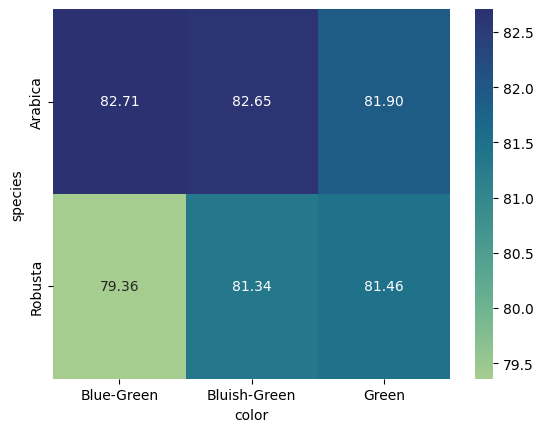

In [12]:
sns.heatmap(coffe_color, annot=True, cmap = 'crest', fmt='.2f')

Сорт кави впливає на оцінку набагато сильніше, ніж колір зерен. Арабіка завжди отримує високі бали, і її колір майже не має значення. А ось для Робусти колір важливий: зелені зерна зазвичай кращі за синьо-зелені. Отже, за кольором можна вгадати якість тільки у дешевших сортів кави.»

# 4. Чи впливає країна походження на якість кави?

In [13]:
mean_point_total_cup = df['total_cup_points'].mean()
print(mean_point_total_cup)

82.08985063480209


In [14]:
mean_cup_points_by_country = df.groupby('country_of_origin')['total_cup_points'].mean().sort_values(ascending=False)
print(mean_cup_points_by_country)

country_of_origin
Papua New Guinea                85.750000
Ethiopia                        85.484091
Japan                           84.670000
United States                   84.433000
Kenya                           84.309600
Panama                          83.707500
Uganda                          83.451944
Colombia                        83.106557
El Salvador                     83.052857
China                           82.927500
Rwanda                          82.830000
Costa Rica                      82.789020
Thailand                        82.573750
Indonesia                       82.565500
Peru                            82.526000
Brazil                          82.405909
Tanzania, United Republic Of    82.369500
Taiwan                          82.001333
Zambia                          81.920000
Guatemala                       81.846575
Laos                            81.833333
Burundi                         81.830000
United States (Hawaii)          81.820411
United States (P

In [15]:
#sns.barplot 